
# **1. Import Libraries**


In [1]:
import os # File paths and directory operations
import cv2 # Computer vision Library for image loading and proeccing
import numpy as np # Numerical comutations and array handling
import pandas as pd # Data manipulation
import seaborn as sns # Visualization
from tqdm import tqdm # Bar used to monitor the progress for loops
from scipy import ndimage # Image filtering
import matplotlib.pyplot as plt # Plotting images and confusion matrix
from skimage.color import rgb2gray # Convert RGB to grayscale
from sklearn.decomposition import PCA # Dimensionality reduction
from torchvision.datasets import CIFAR10,CIFAR100 # Datasets used
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
) # Evaluation metrics

# **2. Load and Visualize Data**


In [2]:
# Load dataset
train_dataset = CIFAR10(root="./data", train=True,  download=True)
test_dataset = CIFAR10(root="./data", train=False, download=True)

# CIFAR-10 Classes
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


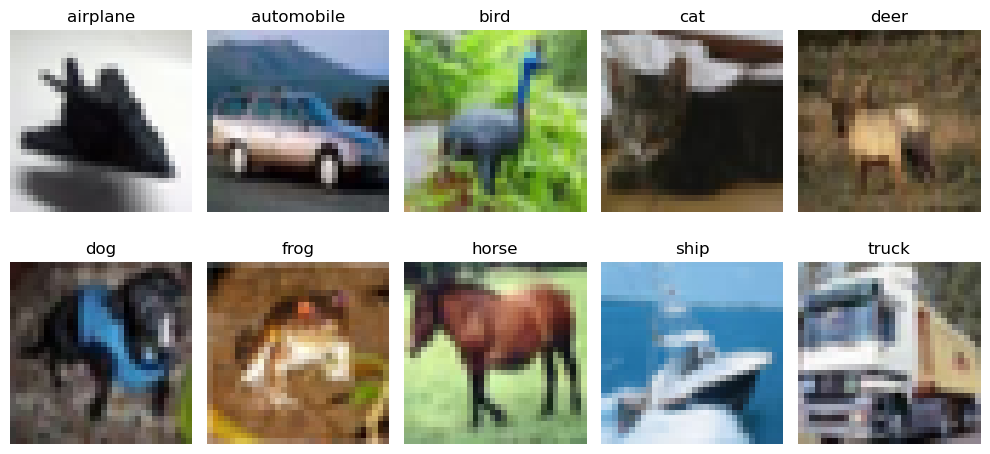

In [3]:
# Display sample images from each CIFAR-10 class
fig, axes = plt.subplots(2,5,figsize = (10,5)) # Create a 2x5 grid showing 10 class
shown = {} # Dictionary to store one example per class

# Loop through training dataset to collect one image for each class
for img,label in train_dataset:
  class_name = classes[label]
  if class_name not in shown:
    shown[class_name] = img
  if len(shown) == len(classes):
    break

# Display each class image in the grid
for i,class_name in enumerate(classes):
  img = shown[class_name]
  row,col = divmod(i,5)
  ax = axes[row,col]
  ax.imshow(img)
  ax.set_title(class_name)
  ax.axis("off")

plt.tight_layout() # Adjust spacing between subplots
plt.show()

# **3. Feature Engineering & Extraction**

      1- Resize image to 64x64
      2- Extract HOG Features
      3- Calculate Mean Vector for each class


In [4]:
# Sobel filter function computes image gradients

def sobel_filters(img):
    Sx = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]], dtype=np.float32) # Horizontal sobel kernal (Vertical edges)

    Sy = np.array([
        [-1,-2,-1],
        [0,0,0],
        [1,2,1]], dtype=np.float32) # Vertical vobel kernal (Horizontal edges)

    # Apply convolution to compute horizontal and vertical gradients
    Gx = ndimage.convolve(img, Sx, mode = 'reflect') # Gradient in X-direction
    Gy = ndimage.convolve(img, Sy, mode = 'reflect') # Gradient in Y-direction

    # Gradient Magnitude (strength)
    G = np.hypot(Gx, Gy)

    # Gradient Direction (orientaton)
    theta = np.arctan2(Gy,Gx)

    # convert orientation to degrees and wrap angles to range [0,180]
    angle = np.rad2deg(theta) % 180.0

    return G, angle # Return magnitude + angle maps

In [5]:
# Compute histogram of oriented gradients (HOG) for each cell
def cell_histograms(G, angle, cell_size = (8,8), nbins = 9):

  h, w = G.shape # Image height and width
  cell_h, cell_w = cell_size # Size of each HOG cell

  n_cells_y = h // cell_h # Number or vertical cells
  n_cells_x = w // cell_w # Number of horizontal cells

  hist = np.zeros((n_cells_y, n_cells_x, nbins)) # Histogramm output (cells_y,cells_x,9bins)
  bin_width = 180.0 / nbins # each bin covers 180/9

  # Loop over each cell position
  for i in range(n_cells_y):
    for j in range(n_cells_x):

      # Cell boundaries
      y0 = i * cell_h
      x0 = j * cell_w

      # Extract magnitude + angle values inside the cell
      mag_cell = G[y0:y0+cell_h, x0:x0+cell_w].ravel()
      angle_cell = angle[y0:y0+cell_h, x0:x0+cell_w].ravel()

      # Determine bins for each pixel based on angle
      bin_indices = angle_cell / bin_width
      lower_bins = np.floor(bin_indices).astype(int) % nbins
      upper_bins = (lower_bins + 1) % nbins

      # Distibute weights between bins
      upper_weight = bin_indices - np.floor(bin_indices)
      lower_weight = 1.0 - upper_weight

      # Accumulate weighted magnitude to the histogram
      for k in range(len(mag_cell)):
        lb = lower_bins[k]  # Lower bin index
        ub = upper_bins[k]  # Upper bin index
        hist[i, j, lb] += mag_cell[k] * lower_weight[k]
        hist[i, j, ub] += mag_cell[k] * upper_weight[k]

  return hist # Return HOG histogram per cell

In [6]:
# Normalizes neighboring cells together
def block_normalize(hist, block_size=(2,2), eps=1e-5):

    n_cells_y, n_cells_x, nbins = hist.shape  # Number of cells and bins
    bh, bw = block_size # Block height/width in cells

    # Number of sliding bloacks available
    n_blocks_y = n_cells_y - bh + 1
    n_blocks_x = n_cells_x - bw + 1
    normalized_blocks = [] # Store flattened, normalized bloack

    # Slide block windo over all possible positions
    for i in range(n_blocks_y):
        for j in range(n_blocks_x):

            # Extract a block of size (bh x bw x nbins)
            block = hist[i:i+bh, j:j+bw, :].ravel()

            # Perform L2-normalization
            norm = np.linalg.norm(block) + eps
            block = block / norm

            # Apply clipping to reduce ontrast (HOG standard practice)
            block = np.clip(block, 0, 0.2) # Clip values to max 0.2

            # Renormalize after clipping
            block = block / (np.linalg.norm(block) + eps)
            normalized_blocks.append(block)

    # If no blocks were generated, return empty array
    if len(normalized_blocks) == 0:
        return np.array([], dtype=np.float32)

    # Concatenate all normalized blocks into one feature vector
    return np.concatenate(normalized_blocks).astype(np.float32)

In [7]:
# Safely normalize a vector
def l2_norm(v):
    # Compute L2 norm (magnitude) of the vector
    n = np.linalg.norm(v)
    return v / n if n != 0 else v # Normalize if norm is non-zero, otherwise return original

In [8]:
# Full handcrafted HOG feature extractor for one image
def extract_hog(img,cell_size=(8,8), block_size=(2,2), nbins=9):

    # Resize image to a 64x64
    img = cv2.resize(img, (64, 64))

    # Convert image from RGB → Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Normalize pixel values to [0,1]
    gray = gray.astype(np.float32) / 255.0

    # Apply Gaussian blur to reduce noise
    gray = ndimage.gaussian_filter(gray, sigma=1)

    # Gradient Calculation using Sobel filter
    magnitude , angle = sobel_filters(gray)

    # Compute cell-level histograms of oriented gradients
    hist = cell_histograms(magnitude, angle, cell_size = cell_size, nbins = nbins)

    # Normalize the histograms via block normalization
    features = block_normalize(hist,block_size= block_size)

    # Apply final L2 normalization for stability
    hog_feat = l2_norm(features)

    # Return final HOG feature vector
    return np.array(hog_feat)

# **4. Image Classification Using Cosine distance**

      1- PCA
      2- Cosine distance


In [9]:
# List to store HOG feature vectors for training images
train_features = []
# List to store ground-truth class labels
train_labels   = []

# Loop through all CIFAR-10 training images and extract handcrafted features
for img, label in tqdm(train_dataset, desc="Extracting Train Features"):
    feat = extract_hog(np.array(img))
    train_features.append(feat)
    train_labels.append(label)

Extracting Train Features: 100%|██████████| 50000/50000 [04:40<00:00, 178.07it/s]


In [10]:
train_features = np.array(train_features) # Convert list of feature vectors into a NumPy array
train_labels   = np.array(train_labels) # Convert list of labels into a NumPy array

In [11]:
pca = PCA(n_components=446) # Initialize PCA to reduce feature dimensions to 446 components
train_reduced = pca.fit_transform(train_features) # Fit PCA on training features and transform them

In [12]:
class_means = {} # Dictionary to store the mean feature vector for each class

# Compute the average PCA-reduced feature vector for each of the 10 CIFAR-10 classes
for c in range(10):
    class_means[c] = train_reduced[train_labels == c].mean(axis=0) # Mvectorean  of class c
    class_means[c] = l2_norm(class_means[c])  # Normalize the mean vector

In [13]:
def predict_cosine_sim(feat):

    feat = l2_norm(feat) # Normalize the raw feature vector
    feat = pca.transform([feat])[0] # Apply PCA reduction to match class-mean dimensions


    best_class = None # Variable to store the most similar class
    best_sim = -999 # Initialize similarity with a very low value

    # Compare feature vector with each class mean using cosine similarity
    for c in range(10):
        sim = np.dot(feat, class_means[c])   # Cosine similarity = dot product between normalized vectors
        if sim > best_sim: # If this class has higher similarity, update best match
            best_sim = sim
            best_class = c

    return best_class, best_sim # Return predicted class + similarity score

In [14]:
y_true = [] # List to store ground-truth labels for test images
y_pred = [] # List to store predicted labels from the model
in_dist_sims = []
# Loop through all CIFAR-10 test images and generate predictions
for img, label in tqdm(test_dataset, desc="Predicting Test Images"):
    feat = extract_hog(np.array(img)) # Extract handcrafted HOG features
    pred,sim = predict_cosine_sim(feat) # Predict class using cosine similarity
    y_true.append(label) # Save the true label
    y_pred.append(pred) # Save the predicted label
    in_dist_sims.append(sim)

Predicting Test Images: 100%|██████████| 10000/10000 [01:18<00:00, 127.51it/s]


In [15]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

In [16]:
print("\n  Evaluation Metrics")
print('---------------------------')
print(f"Accuracy  :    {accuracy*100:.2f}%")
print(f"Precision :    {precision*100:.2f}%")
print(f"Recall    :    {recall*100:.2f}%")
print(f"F1 Score  :    {f1*100:.2f}%")


  Evaluation Metrics
---------------------------
Accuracy  :    41.82%
Precision :    42.18%
Recall    :    41.82%
F1 Score  :    41.51%


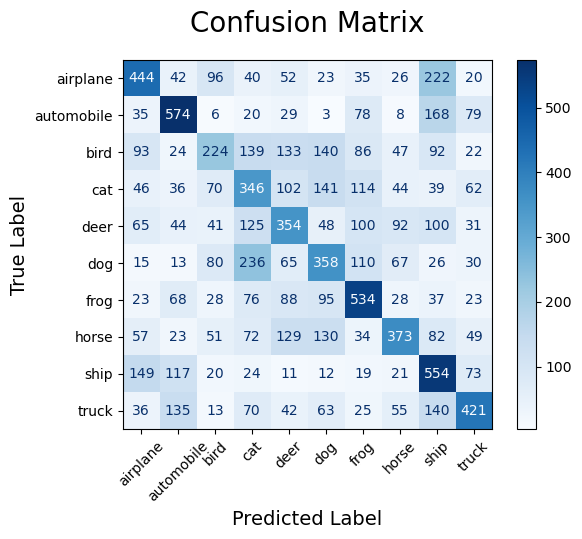

In [17]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix", fontsize=20, pad=20)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.show()

# **5. Load CIFAR-100 Dataset as OOD Data**


In [18]:
from torchvision.datasets import CIFAR100   # import CIFAR-100 dataset class

# Load CIFAR-100 test split.
# We use it as OOD because none of its classes overlap with CIFAR-10.
ood_dataset = CIFAR100(root='./data', train=False, download=True)

# Lists to store OOD images and their labels
ood_images = []
ood_labels = []

# Loop through the entire CIFAR-100 dataset
for img, label in ood_dataset:
    ood_images.append(np.array(img))   # convert PIL image to NumPy array
    ood_labels.append(label)           # save the class label (not used for OOD detection)

# Print total number of OOD samples
print("Total OOD images:", len(ood_images))


Total OOD images: 10000


In [19]:
# ------------------------------------------------------------
# Display Classes of First 20 OOD (CIFAR-100) Samples
# ------------------------------------------------------------

print("Classes of the 20 sampled OOD images:\n")   # header text

for i in range(20):                     # loop through first 20 images
    img, label = ood_dataset[i]         # get image + label
    print(f"Image {i}: class = {ood_dataset.classes[label]}")  # print class name


Classes of the 20 sampled OOD images:

Image 0: class = mountain
Image 1: class = forest
Image 2: class = seal
Image 3: class = mushroom
Image 4: class = sea
Image 5: class = tulip
Image 6: class = camel
Image 7: class = butterfly
Image 8: class = cloud
Image 9: class = apple
Image 10: class = sea
Image 11: class = skunk
Image 12: class = streetcar
Image 13: class = rocket
Image 14: class = lamp
Image 15: class = lion
Image 16: class = tulip
Image 17: class = wolf
Image 18: class = rose
Image 19: class = orange


# **Handcrafted OOD Detection**





In [20]:
# ------------------------------------------------------------
# 6) Compute IN-DIST similarities (CIFAR-10 test set)
# ------------------------------------------------------------

in_dist_sims = []   # List to store similarity scores for in-distribution samples

print("Computing IN-DIST similarities...")  # Display progress message

for img, label in test_dataset:    # Loop through each image and label in CIFAR-10 test set
    img_np = np.array(img)         # Convert PIL image to a NumPy array

    # extract handcrafted HOG
    feat = extract_hog(img_np)     # Compute handcrafted HOG feature vector for the image

    # L2 normalization once
    feat = l2_norm(feat)           # Normalize feature vector using L2 normalization

    # apply PCA (same PCA from training)
    feat_pca = pca.transform(feat.reshape(1, -1))[0]  # Apply trained PCA, reshape required for sklearn API

    # cosine similarity with class means
    sims = []                      # Temporary list to store similarities with each class mean
    for c in range(10):            # Loop over the 10 CIFAR-10 classes
        num = np.dot(feat_pca, class_means[c])   # Dot product (numerator of cosine similarity)
        den = (np.linalg.norm(feat_pca) * np.linalg.norm(class_means[c]) + 1e-8)  # L2 norms product (denominator)
        sims.append(num / den)     # Append cosine similarity score

    best_sim = max(sims)           # Take the highest similarity across all classes (predicted class similarity)
    in_dist_sims.append(best_sim)  # Store this similarity score for evaluation

in_dist_sims = np.array(in_dist_sims)  # Convert list to NumPy array for later processing


Computing IN-DIST similarities...


In [21]:
# ------------------------------------------------------------
# 7) Compute OOD similarities (CIFAR-100)
# ------------------------------------------------------------

ood_sims = []   # List to store similarity scores for out-of-distribution (CIFAR-100) samples

print("Computing OOD similarities...")  # Display progress message

for img, label in ood_dataset:      # Loop through each OOD image in the CIFAR-100 dataset
    img_np = np.array(img)          # Convert PIL image to a NumPy array

    feat = extract_hog(img_np)      # Extract handcrafted HOG feature vector
    feat = l2_norm(feat)            # Apply L2 normalization to the feature vector
    feat_pca = pca.transform(feat.reshape(1, -1))[0]  # Reduce dimensionality using trained PCA

    sims = []                       # List to store similarities with each CIFAR-10 class mean
    for c in range(10):             # Loop over the 10 known CIFAR-10 classes
        num = np.dot(feat_pca, class_means[c])  # Compute dot product (cosine similarity numerator)
        den = (np.linalg.norm(feat_pca) * np.linalg.norm(class_means[c]) + 1e-8)  # Compute denominator with L2 norms
        sims.append(num / den)      # Store cosine similarity value

    best_sim = max(sims)            # Highest similarity score among all classes
    ood_sims.append(best_sim)       # Append the best similarity score to OOD list

ood_sims = np.array(ood_sims)       # Convert list to NumPy array for further analysis


Computing OOD similarities...


In [22]:
from sklearn.metrics import roc_curve   # import ROC curve function

# ------------------------------------------------------------
# 8) Compute optimal threshold using ROC + Youden’s J
# ------------------------------------------------------------

scores = np.concatenate([in_dist_sims, ood_sims])  # combine IN-DIST and OOD similarity scores
labels = np.concatenate([np.ones_like(in_dist_sims), np.zeros_like(ood_sims)])  # labels: 1 = IN-DIST, 0 = OOD

fpr, tpr, thr = roc_curve(labels, scores)  # compute FPR, TPR, and threshold values for ROC curve

J = tpr - fpr  # compute Youden’s J statistic for each threshold
best_idx = np.argmax(J)  # find index of threshold that maximizes J
threshold = thr[best_idx]  # extract the optimal threshold

print("Optimal Threshold =", threshold)  # print the chosen threshold


Optimal Threshold = 0.2226352326155044


In [23]:
# ------------------------------------------------------------
# 9) Compute AUROC (Area Under the ROC Curve)
# ------------------------------------------------------------
from sklearn.metrics import roc_auc_score   # import function to compute the AUROC metric

auroc = roc_auc_score(labels, scores)      # calculate AUROC using true labels and similarity scores

print("\n===== AUROC Evaluation =====")      # print a header for clarity in output
print(f"AUROC Score : {auroc:.4f}")         # display the AUROC value formatted to 4 decimal places



===== AUROC Evaluation =====
AUROC Score : 0.5166


In [24]:
# ------------------------------------------------------------
#10) Compute FPR at 95% TPR (FPR@95)
# ------------------------------------------------------------

# target TPR value to check (we want the point where TPR reaches 0.95)
target = 0.95

# find all indices where the TPR is greater than or equal to 0.95
idx = np.where(tpr >= target)[0]

# if such an index exists, use the corresponding FPR value
if len(idx) > 0:
    fpr95 = fpr[idx[0]]        # FPR at the first point where TPR >= 0.95
else:
    fpr95 = 1.0                # worst-case scenario if TPR never reaches 0.95

# print the final FPR@95 result, formatted to 4 decimal places
print(f"FPR@95%TPR = {fpr95:.4f}")


FPR@95%TPR = 0.9434


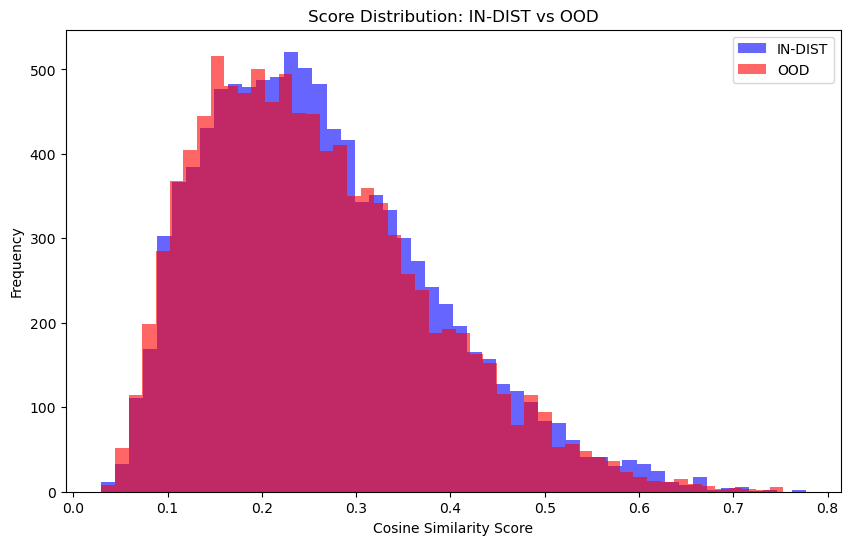

In [25]:
# ------------------------------------------------------------
# 11) Visualization: Score Distribution Histogram (IN-DIST vs OOD)
# ------------------------------------------------------------

plt.figure(figsize=(10,6))                         # create a figure with a defined size for better visibility
plt.hist(in_dist_sims, bins=50, alpha=0.6,
         label="IN-DIST", color='blue')            # plot histogram of IN-DIST similarity scores
plt.hist(ood_sims, bins=50, alpha=0.6,
         label="OOD", color='red')                 # plot histogram of OOD similarity scores
plt.xlabel("Cosine Similarity Score")              # set x-axis label to indicate what scores represent
plt.ylabel("Frequency")                            # set y-axis label for the count of samples
plt.title("Score Distribution: IN-DIST vs OOD")    # set the title explaining the comparison
plt.legend()                                       # add legend to differentiate the two distributions
plt.show()                                         # render the histogram on the screen


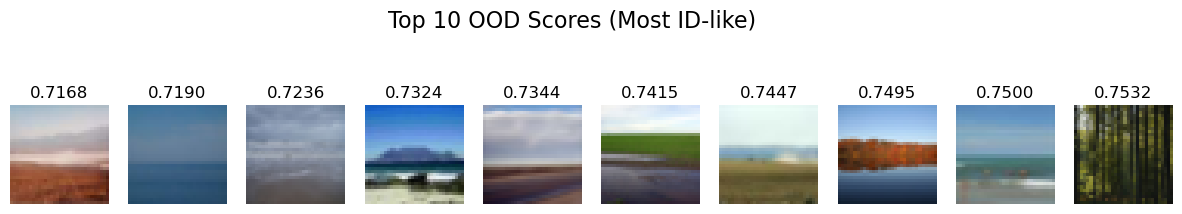

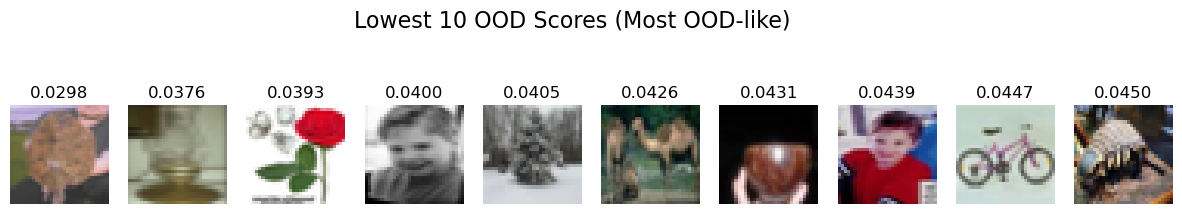

In [26]:
# ------------------------------------------------------------
# 12) Visualization: Top & Lowest OOD Scores (Most ID-like vs Most OOD-like)
# ------------------------------------------------------------

# Combine CIFAR-100 OOD images and their corresponding arrays for visualization
ood_images = [np.array(img) for img, _ in ood_dataset]   # convert CIFAR-100 images to NumPy arrays

scores_arr = ood_sims  # OOD similarity scores only

# get indices of the top 10 highest OOD scores (most similar to IN-DIST)
top_idx = np.argsort(scores_arr)[-10:]

# get indices of the lowest 10 OOD scores (most dissimilar → strongly OOD)
low_idx = np.argsort(scores_arr)[:10]


def plot_samples(indices, title):
    plt.figure(figsize=(15,3))                      # create a wide row of images
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i+1)           # place each image side-by-side
        img = ood_images[idx]                       # get the image using the index
        plt.imshow(img)                             # display the image
        plt.title(f"{scores_arr[idx]:.4f}")         # show its similarity score
        plt.axis("off")                             # hide axis ticks and borders
    plt.suptitle(title, fontsize=16)                # add a main title for the group
    plt.show()                                      # render the plot


# display the top 10 OOD samples (those most similar to IN-DIST)
plot_samples(top_idx, "Top 10 OOD Scores (Most ID-like)")

# display the lowest 10 OOD samples (those most clearly OOD)
plot_samples(low_idx, "Lowest 10 OOD Scores (Most OOD-like)")
